In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns

In [2]:
fce = pd.read_csv("../datasets/farm_cat_eco.csv")

In [3]:
fce.head()


,year,territory,lambs,rams,ewes,lamb_sheep_shorn,sheep_flock,sheep_purchased,cats_occurrence_total,cats_forest,...,eco_sector_authorities_stakeholders,eco_sector_environment,eco_sector_health,eco_type_control,eco_type_control_education,eco_type_control_medical_care,eco_type_control_prevention,eco_type_damage_loss,eco_type_eradication,eco_type_prevention
0,2002,All Australia,10658.0,662.0,26531.0,51883.0,47861.0,3300.0,197.0,77.0,...,825276.359414,0.0,0.0,825276.359414,0.0,0.0,0.0,0.0,0.0,0.0
1,2002,New South Wales,2624.0,131.0,5996.0,11360.0,10544.0,770.0,104.0,46.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2002,Northern Territory,0.0,0.0,0.0,0.0,0.0,0.0,34.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2002,Queensland,1421.0,103.0,5020.0,11123.0,9707.0,584.0,24.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2002,South Australia,2148.0,137.0,5372.0,8857.0,8938.0,692.0,18.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
## All Australia
aus = fce[fce["territory"] == "All Australia"]

# Categorization 

In [5]:
## Type of costs diviation 
cost_types = [
    "eco_type_control",
    "eco_type_damage_loss",
    "eco_type_eradication",
    "eco_type_prevention"
]

cost_structure = aus[cost_types].sum()
cost_structure = cost_structure.round(0).astype(int)
cost_structure

eco_type_control         2282268
eco_type_damage_loss     7940169
eco_type_eradication    33836150
eco_type_prevention      1213341
dtype: int64

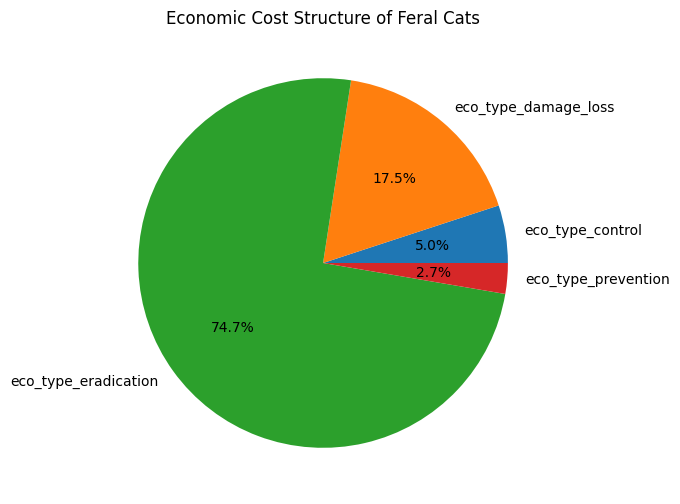

In [6]:
## Visualizing

cost_structure.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Economic Cost Structure of Feral Cats")
plt.ylabel("")
plt.show()

# Control Vs. Damage

In [7]:
## Control Costs categorization
control_cost = (
    cost_structure["eco_type_control"]
    + cost_structure["eco_type_eradication"]
    + cost_structure["eco_type_prevention"]
)

In [12]:
## Damage Cost Categorization
damage_cost = cost_structure["eco_type_damage_loss"]

In [9]:
comparison = pd.Series({
    "Control spending": control_cost,
    "Damage losses": damage_cost
})

comparison

Control spending    37331759
Damage losses        7940169
dtype: int64

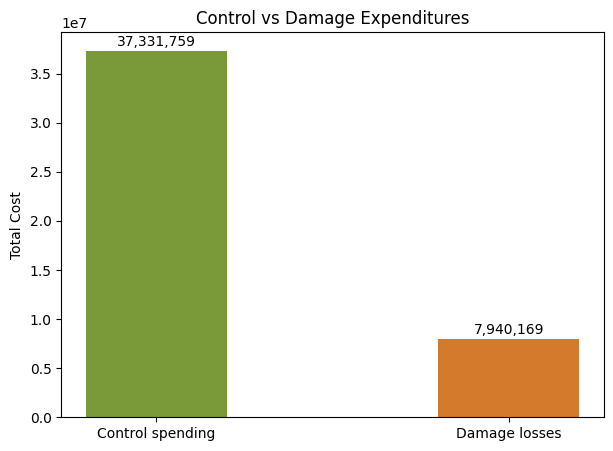

In [26]:
## Visualization of the control VS. damage stats
labels = comparison.index
values = comparison.values

x = np.arange(len(labels))

plt.figure(figsize=(7,5))

plt.bar(x, values, width=0.4, color=["#7a9a3a", "#d47a2c"])

plt.xticks(x, labels)
plt.ylabel("Total Cost")
plt.title("Control vs Damage Expenditures")

for i, v in enumerate(values):
    plt.text(i, v + 500000, f"{v:,.0f}", ha="center")

plt.show()

## Temporal Dynamics of Economic Cost

First, we aggrigate overall economics cost by year

In [33]:
## Costs by year depedning on the type of loss
cost_by_year = aus.groupby("year")[cost_types].sum()

cost_by_year = cost_by_year.applymap(lambda x: f"{x:,.0f}")
cost_by_year

C:\Users\User\AppData\Local\Temp\ipykernel_18848\964814017.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cost_by_year = cost_by_year.applymap(lambda x: f"{x:,.0f}")


,eco_type_control,eco_type_damage_loss,eco_type_eradication,eco_type_prevention
year,,,,
2002,"825,276",0,0,0
2003,0,0,0,0
2004,"1,180,696",0,0,0
2005,0,0,0,0
2006,"11,185",0,"3,139,774",0
2007,0,0,0,0
2008,0,0,0,0
2009,0,0,0,0
2010,"11,162",0,"29,227",0


### Cost dynamics by category

To compare how different cost categories evolve over time, we visualize each category in a separate subplot.  
All plots share the same scale to allow a direct comparison of expenditure levels across categories.

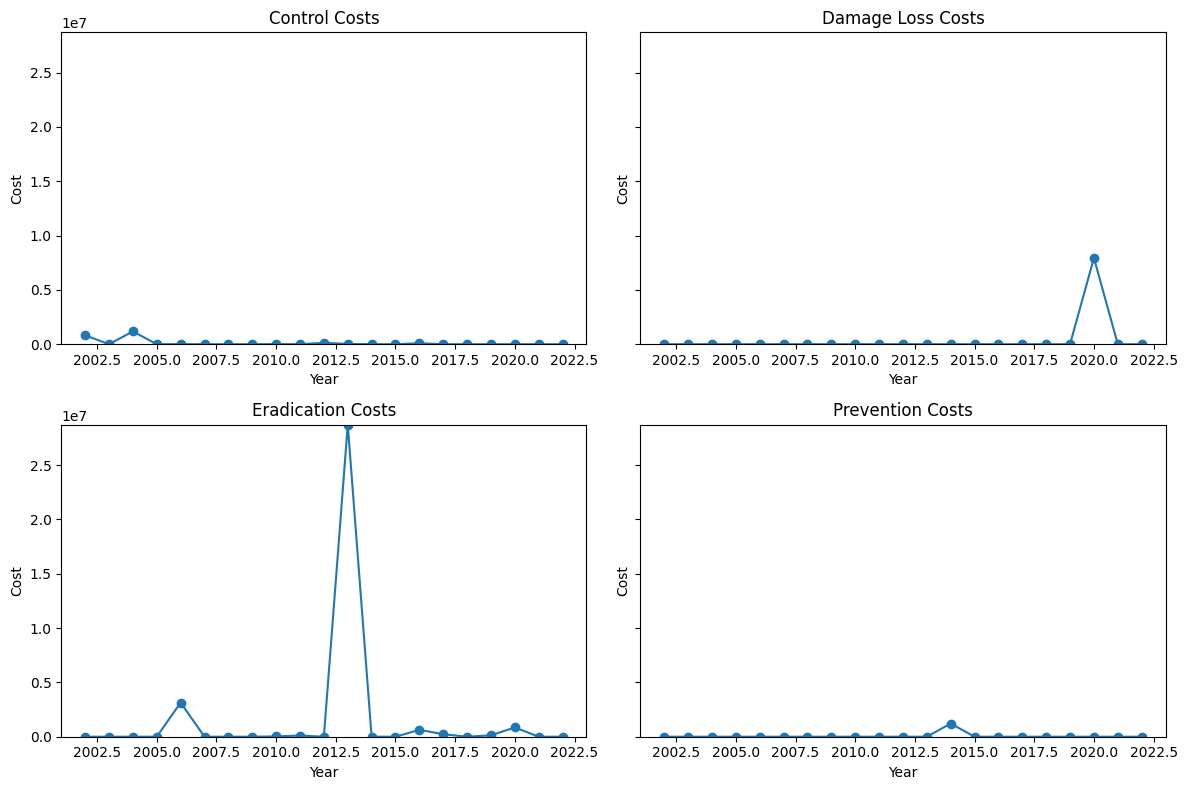

In [35]:

nice_names = {
    "eco_type_control": "Control Costs",
    "eco_type_damage_loss": "Damage Loss Costs",
    "eco_type_eradication": "Eradication Costs",
    "eco_type_prevention": "Prevention Costs"
}


max_val = cost_by_year.max().max()

fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=True)

axes = axes.flatten()

for i, col in enumerate(cost_types):
    axes[i].plot(cost_by_year.index, cost_by_year[col], marker="o")
    axes[i].set_title(nice_names[col])
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Cost")
    axes[i].set_ylim(0, max_val)  

plt.tight_layout()
plt.show()

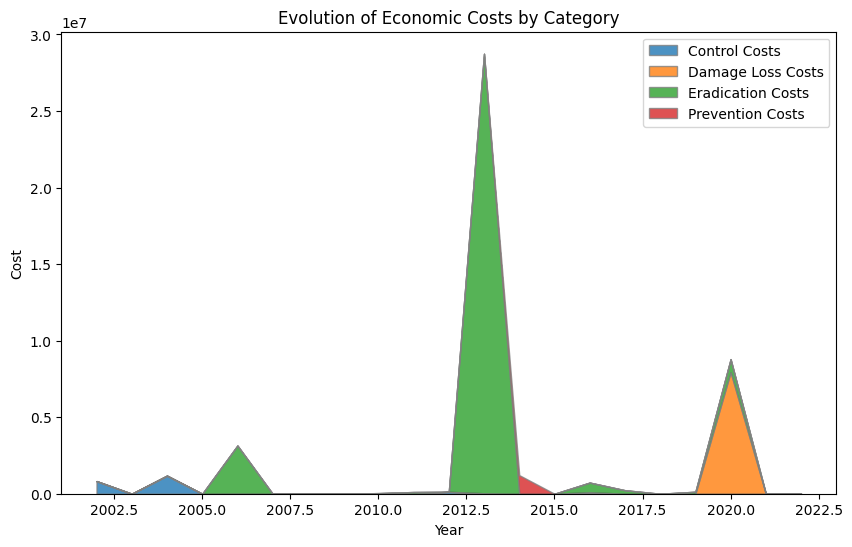

In [41]:
plot_data = cost_by_year.rename(columns=nice_names)

plt.figure(figsize=(10,6))

plt.stackplot(
    plot_data.index,
    plot_data.T,
    labels=plot_data.columns,
    alpha=0.8,
    edgecolor="gray",
    linewidth=1
)

plt.title("Evolution of Economic Costs by Category")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.show()

### Total economic cost over time

Next, we calculate the total economic cost per year by summing all cost categories.  
This helps us observe how the overall economic impact of feral cats changes across years.

In [29]:
total_cost_year = cost_by_year.sum(axis=1)
total_cost_year

year
2002            825,276000
2003                  0000
2004          1,180,696000
2005                  0000
2006     11,18503,139,7740
2007                  0000
2008                  0000
2009                  0000
2010        11,162029,2270
2011            00111,7940
2012        126,80201,1020
2013    29,462028,708,1600
2014      2,023001,213,341
2015                  0000
2016       95,6610633,2650
2017            00230,1420
2018                  0000
2019            00130,2970
2020    07,940,169852,3880
2021                  0000
2022                  0000
dtype: object

### Visualizing total cost dynamics

We plot the evolution of total economic costs over time to identify trends, spikes, or periods of intensified management efforts.

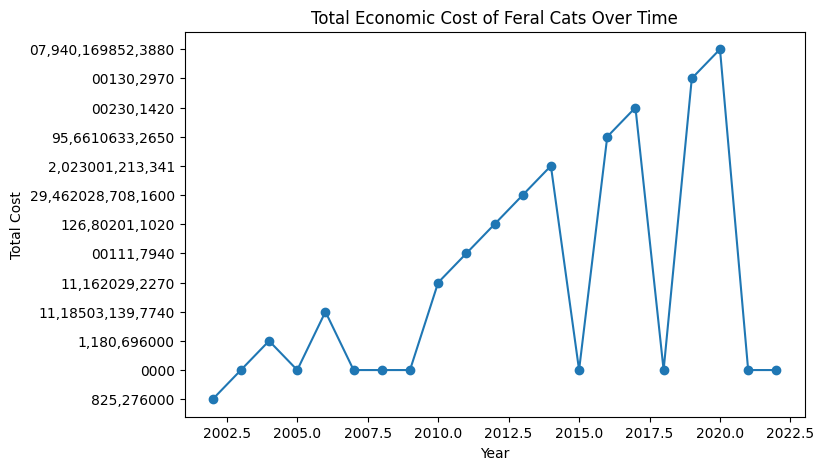

In [30]:

plt.figure(figsize=(8,5))

plt.plot(total_cost_year.index, total_cost_year.values, marker="o")

plt.title("Total Economic Cost of Feral Cats Over Time")
plt.xlabel("Year")
plt.ylabel("Total Cost")

plt.show()

dkmdk

In [44]:
fce_states = fce[fce["territory"] != "All Australia"]


In [48]:
median_cats = fce_states["cats_occurrence_total"].median()
median_cats

np.float64(64.0)

In [52]:
fce_states["cat_group"] = (
    fce_states["cats_occurrence_total"] > median_cats
)
fce_states["cat_group"].value_counts()

C:\Users\User\AppData\Local\Temp\ipykernel_18848\2503073003.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fce_states["cat_group"] = (


cat_group
False    95
True     63
Name: count, dtype: int64

In [53]:
fce_states["sheep_flock"].isna().sum()

np.int64(11)

In [55]:
high = fce_states[fce_states["cat_group"]]["sheep_flock"].dropna()
low = fce_states[~fce_states["cat_group"]]["sheep_flock"].dropna()

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 4.030299430602475
p-value: 9.226844214269879e-05


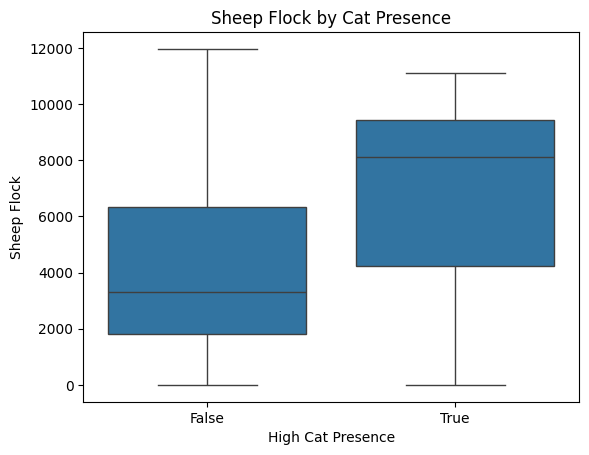

In [58]:
sns.boxplot(data=fce_states, x="cat_group", y="sheep_flock")

plt.xlabel("High Cat Presence")
plt.ylabel("Sheep Flock")
plt.title("Sheep Flock by Cat Presence")

plt.show()